In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os
from scipy.optimize import curve_fit

import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.dpi'] = 300
from PythonAnalysis import *


In [2]:
N_bootstrap = 10000
FTMethod = "LSFT"
fontsize = 15
kappa = 20
FrameTension="AnisotropicFrameTension"
InitialConfiguration = "FromFlat"
i1 = 0
i2 = 10
N_k = 10

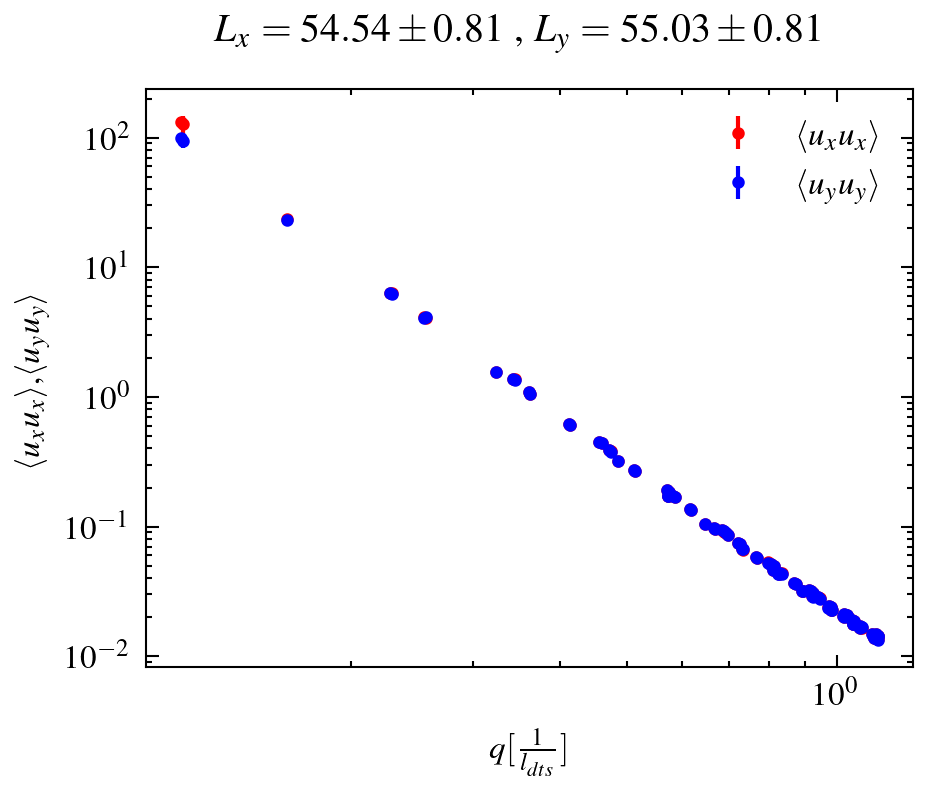

In [ ]:
Simulation = "OnlyMembrane"
#Simulation = "VFMCoupling"
UndulationSpectrum(InitialConfiguration="FromEquilibrium",plot_func="q",N_bootstrap=100000,i1=1,i2=5,
                   FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod)

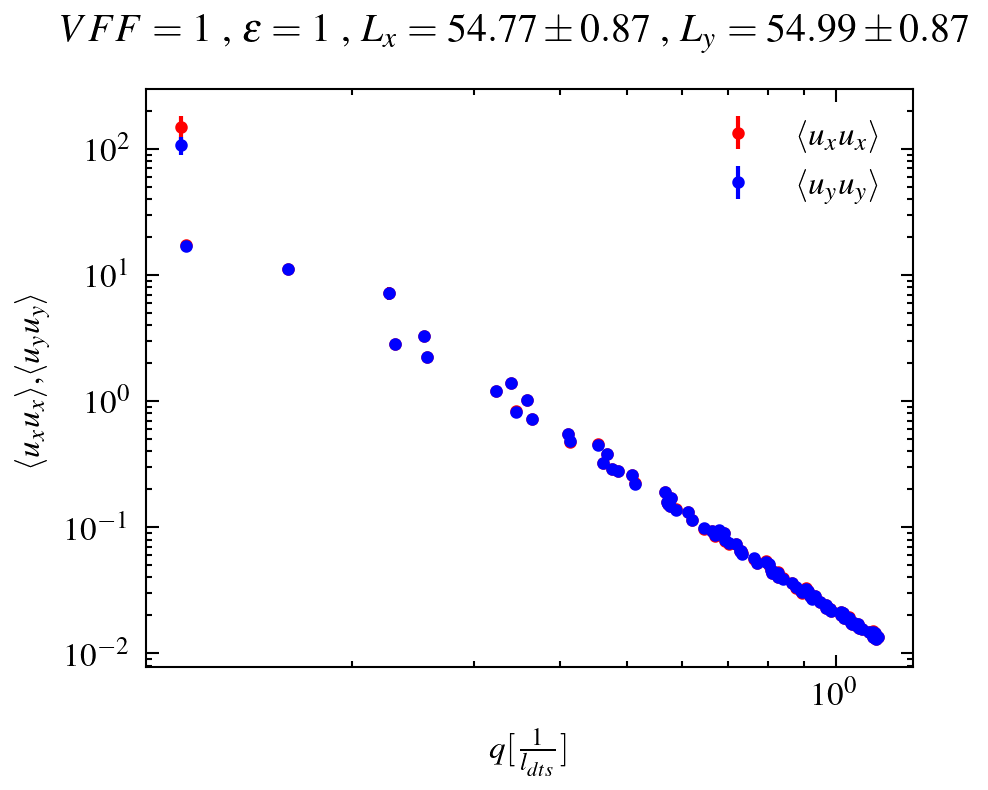

In [4]:
#Simulation = "OnlyMembrane"
Simulation = "OnlyVectorField"
UndulationSpectrum(VFF="1",EPS="1",InitialConfiguration="FromFlat",plot_func="q",N_bootstrap=100000,i1=0,i2=5,
                   FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod)

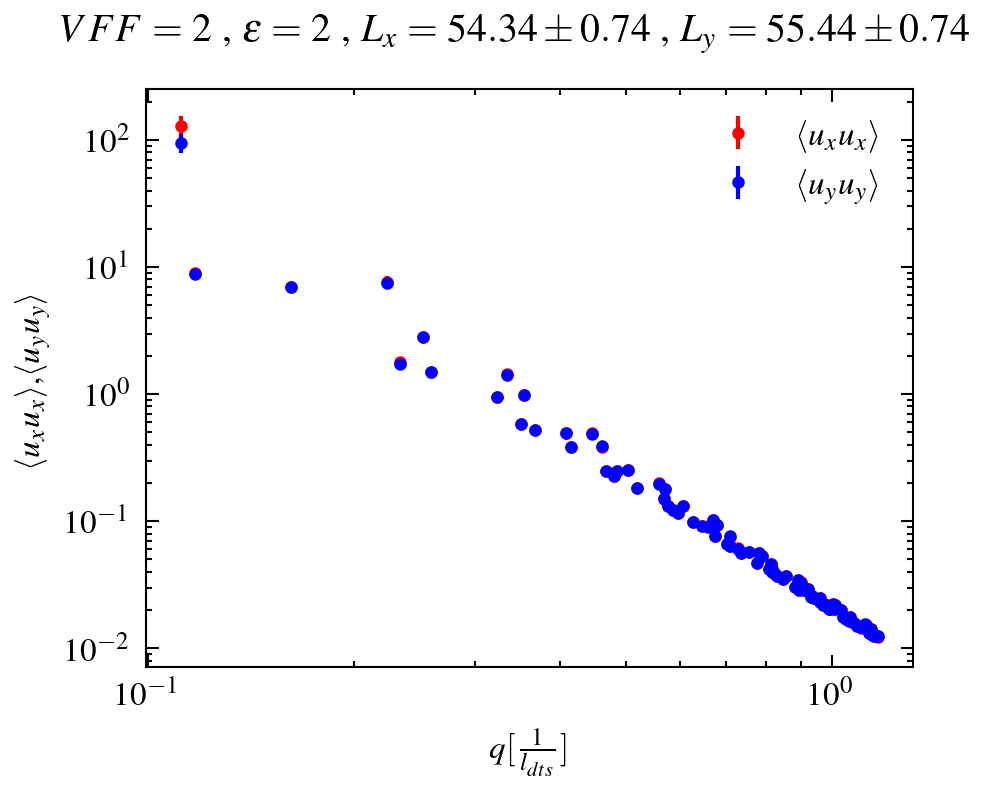

In [5]:
Simulation = "OnlyVectorField"
UndulationSpectrum(VFF="2",EPS="2",InitialConfiguration="FromFlat",plot_func="q",N_bootstrap=100000,i1=0,i2=5,
                   FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod)

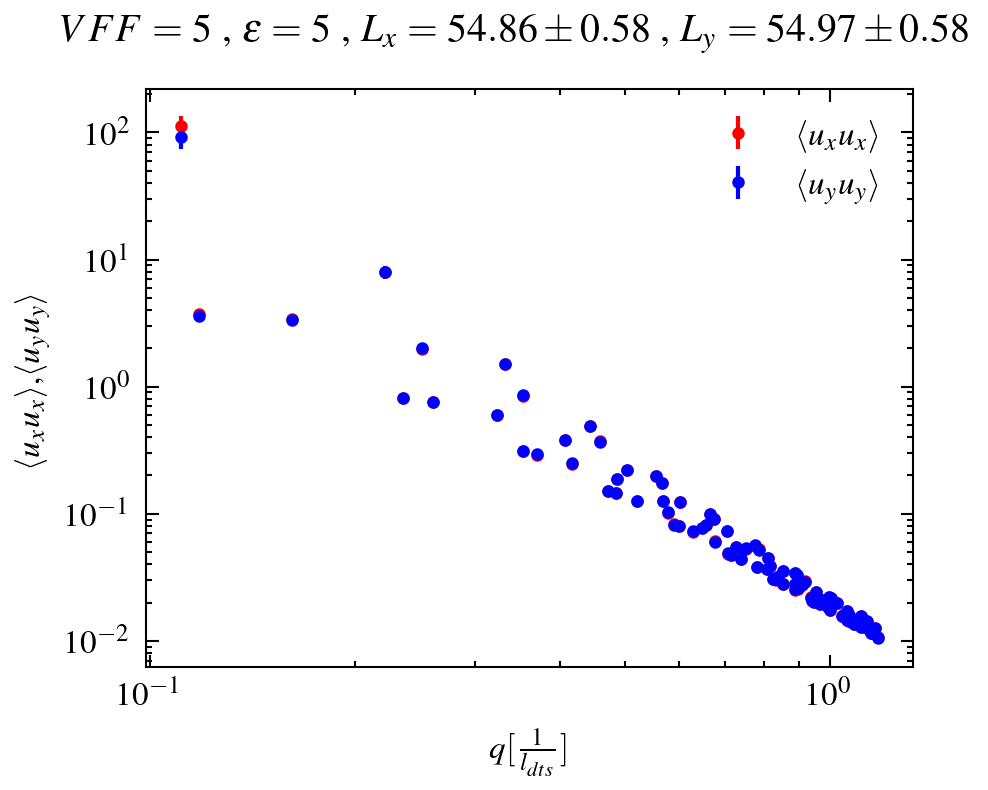

In [6]:
Simulation = "OnlyVectorField"
UndulationSpectrum(VFF="5",EPS="5",InitialConfiguration="FromFlat",plot_func="q",N_bootstrap=100000,i1=0,i2=5,
                   FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod)

In [7]:
sfdsfd

NameError: name 'sfdsfd' is not defined

In [ ]:
Simulation = "VectorFieldMembrane"
EPS="10"
KPKL_list=[(0.1,0.05),(1,0.5),(10,5)]
for KPKL in KPKL_list:
# start bootstrapping
    for N_k in (3,5,8):
        values = np.genfromtxt(
            f"/lustre/astro/semygind/Analyzer/version_1/{Simulation}/EPS{EPS}/KP{KPKL[0]}KL{KPKL[1]}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt",
#            /lustre/astro/semygind/Analyzer/version_1/VectorFieldMembrane/EPS10/KP0.1KL0.05/StaticUndulationSpectrum/LSFT3.txt
            skip_header=7,
            delimiter=" ",
        )
        
        mean, err = bootstrap(values,N_bootstrap)
        #r"$n \pm \sigma_n$",r"$\kappa",r"$\kappa_{\parallel}$",r"\kappa_{perpindicular}$",r"$\epsilon$",r"$\xi$",r"$N_k$"
        table_data.append([
        rf"${mean[1]:.2f} \pm {err[1]:.2f}$",
        rf"${kappa}$",
        rf"${KPKL[0]}$",
        rf"${KPKL[1]}$",
        rf"${EPS}$",
        rf"$0$",
        rf"{N_k}"
        ])

    #_ = plt.hist(bootstrap_params[:,1], bins='scott', density=True, label=rf"PDF $N_k={N_k}$")
    #mu, std = norm.fit(bootstrap_params[:,1])
    #x = np.linspace(bootstrap_params[:,1].min(), bootstrap_params[:,1].max(), 300)
    #plt.plot(x, norm.pdf(x, mean, ), color='red', label=rf"$n={mu:.2f},\ \sigma={std:.2f}$")
    #plt.vlines(mu,0,norm.pdf(mu,mu,std),color="black",label="Mean",linestyles="dashed")
    #plt.legend()
    # 4.46
    # N_k5 -> 4.46
    # N_k7 -> 4.47
    # 100k -> 
#plt.show()